# 02 · Data quality and reconciliation

This notebook is not housekeeping: it is the first slide of the deck. Two of
the findings here change what the other three notebooks are allowed to claim.

The questions, in order of how much damage a wrong answer does:

1. Does the dataset agree with the FY2025 annual report? *(No.)*
2. Is every employee exposed to the same number of surveys? *(No, and Angle 3
   breaks if you miss it.)*
3. Is `tenure_months` a fact or a stale derived field? *(Stale.)*
4. Is the observation window complete at both ends? *(No: December 2025 is cut off.)*

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "etl.py").exists())
sys.path.insert(0, str(_root / "src"))

from nbinit import *

emp = load("employees_clean")
att = load("attrition_clean")
eng = load("engagement_clean")
perf = load("performance_clean")
df = load("analysis_df")

## 1. Column-level profile

Written to `clean/data_quality.csv` so the DQ slide rebuilds from a file,
not a screenshot.

In [2]:
dq = pd.concat(
    [etl.profile(frame, name) for name, frame in
     [("employees", emp), ("attrition", att), ("engagement", eng), ("performance", perf)]],
    ignore_index=True,
)

dq.to_csv(CLEAN / "data_quality.csv", index=False)
print(f"\n  wrote {(CLEAN / 'data_quality.csv').relative_to(ROOT)}  ({len(dq)} columns profiled)")


  [employees] 13,403 rows
    duplicate employee_id: 0
    columns with nulls:
      exit_date                         89.55%
      manager_id                         0.01%

  [attrition] 1,400 rows
    duplicate employee_id: 0

  [engagement] 55,971 rows
    duplicate employee_id: 42,875
    columns with nulls:
      manager_effectiveness             18.34%
      psychological_safety              18.34%
      recognition                       18.34%
      career_development                18.34%
      senior_leadership_trust           18.34%
      purpose_meaning                   18.34%
      wellbeing                         18.34%
      confidence_in_role_future         18.34%

  [performance] 34,979 rows
    duplicate employee_id: 21,685

  wrote clean\data_quality.csv  (53 columns profiled)


### Are the nulls a problem, or are they structure?

Every null here is explainable, which is worth stating: missingness is not
the story.

In [3]:
nulls = dq[dq["pct_null"] > 0].sort_values("pct_null", ascending=False)
nulls[["table", "column", "dtype", "n_null", "pct_null"]]

,table,column,dtype,n_null,pct_null
3,employees,exit_date,datetime64[us],12003,89.55
38,engagement,manager_effectiveness,float64,10264,18.34
42,engagement,senior_leadership_trust,float64,10264,18.34
39,engagement,psychological_safety,float64,10264,18.34
40,engagement,recognition,float64,10264,18.34
41,engagement,career_development,float64,10264,18.34
44,engagement,wellbeing,float64,10264,18.34
43,engagement,purpose_meaning,float64,10264,18.34
45,engagement,confidence_in_role_future,float64,10264,18.34
17,employees,manager_id,string,1,0.01


- `exit_date` null for 89.6% of employees: those are the 12,003 actives. Structural.
- the eight engagement dimensions null for 18.3% of rows: those are the
  non-responses. Structural, and in Angle 3 it is the *signal*, not a gap.
- `manager_id` null once. Immaterial.

So: no imputation needed anywhere. State that explicitly in the deck: it
pre-empts the obvious question.

## 2. Reconciliation against the FY2025 annual report

**This is the finding.** The annual report says 1,400 departures *in FY2025*.
The attrition log has 1,400 rows: spread across *24 months*. Both cannot be
true, and which one is right changes every cost number in Angle 1.

In [4]:
etl.reconcile(emp, att)


RECONCILIATION vs FY2025 ANNUAL REPORT
  Active employees in data     : 12,003   (annual report: 12,003)
  Total roster rows            : 13,403
  Attrition log rows           : 1,400   (annual report FY25: 1,400)

  Exits by calendar year:
    2024: 680
    2025: 720

  Exits in FY2025 window       : 846   (annual report: 1,400)
  FY2025 voluntary attrition   : 5.7%   (annual report: 10.4%)
  Verdict                      : >>> MATERIAL DISCREPANCY <<<

  Attrition rows with no matching employee: 0


  Departed employees absent from log      : 0


### Where the 1,400 actually sit in time

In [5]:
by_month = (
    att["exit_date"].dt.to_period("M").value_counts().sort_index()
    .rename("exits").rename_axis("month").reset_index()
)
by_month["month"] = by_month["month"].dt.to_timestamp()

fy25 = by_month.loc[by_month["month"].between("2024-07-01", "2025-06-30"), "exits"].sum()
print(f"  total exits in log        : {by_month['exits'].sum():,}")
print(f"  exits inside FY2025       : {fy25:,}")
print(f"  annual report FY2025      : {etl.AR_DEPARTURES_FY25:,}")
print(f"  shortfall                 : {etl.AR_DEPARTURES_FY25 - fy25:,}")

  total exits in log        : 1,400
  exits inside FY2025       : 846
  annual report FY2025      : 1,400
  shortfall                 : 554


  saved figures\dq_exits_by_month.png


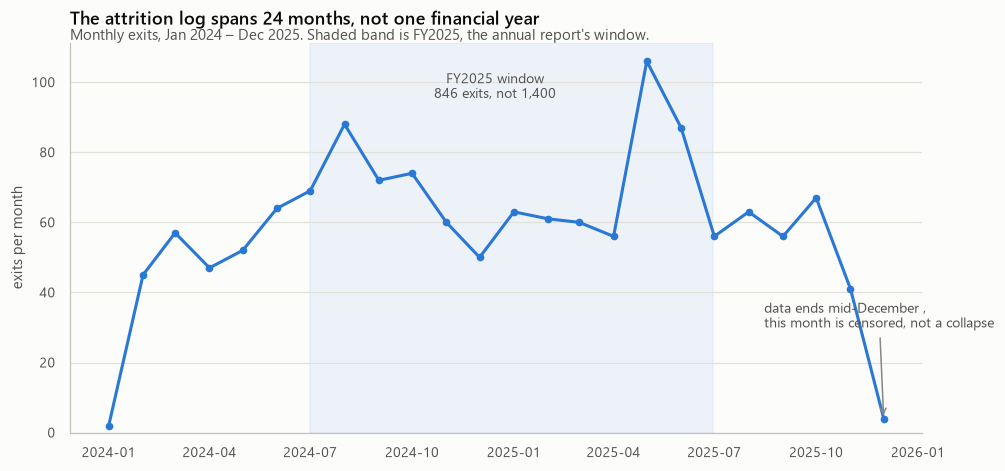

In [6]:
fig, ax = figure(
    "The attrition log spans 24 months, not one financial year",
    "Monthly exits, Jan 2024 – Dec 2025. Shaded band is FY2025, the annual report's window.",
    figsize=(10, 4.6),
)

ax.axvspan(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-06-30"),
           color=SERIES[0], alpha=0.07, zorder=0)
ax.plot(by_month["month"], by_month["exits"], color=SERIES[0], marker="o",
        markersize=4, zorder=3)

ax.annotate(f"FY2025 window\n{fy25:,} exits, not {etl.AR_DEPARTURES_FY25:,}",
            xy=(pd.Timestamp("2024-12-15"), by_month["exits"].max() * 0.97),
            ha="center", va="top", fontsize=9, color=INK["secondary"])
ax.annotate("data ends mid-December ,\nthis month is censored, not a collapse",
            xy=(pd.Timestamp("2025-12-01"), 4), xytext=(pd.Timestamp("2025-08-15"), 30),
            fontsize=9, color=INK["secondary"],
            arrowprops=dict(arrowstyle="->", color=INK["muted"], lw=1))

ax.set(ylabel="exits per month", xlabel="", ylim=(0, None))
save_fig(fig, "dq_exits_by_month")
plt.show()

### Verdict

Two readings, and they are not equally defensible:

| Reading | Implication |
|---|---|
| The log is complete and the annual report counts a wider population (contractors, transfers, or a different entity set) | The 10.4% headline attrition is not reproducible from this data: say so, and quote the 24-month rate instead |
| The log is a 60% sample of FY2025 departures | Every cost figure derived from it is a **floor**, and Angle 1's answer is "the $42M is understated, and here is by how much" |

Either way, **do not present a headline attrition rate as if it reconciles.**
The 5.7% FY2025 voluntary rate computed from this data against the 10.4%
published rate is the single most important slide in the deck.

## 3. Survey exposure is not equal: the Angle 3 trap

"Entity" here means `legacy_entity_code`: the legacy business an employee's
record came from. NovaCorp is a merged group, and each constituent arrived
with its own HRIS: `NovaCorp-Origin` (8,555 employees, WorkdayHR) is the
original company; `Entity_A` (1,950, SAP-HR), `Entity_B` (1,884,
BambooHR-EntityB) and `Entity_C` (1,014, PeopleSoft-Legacy) are the acquired
businesses. It is a data-lineage field, not a FAR-licensed entity: Angle 2's
waves cut a different way.

Five survey waves ran between Feb 2024 and Aug 2025. But two of the acquired
entities were only onboarded onto the survey platform partway through
(`Entity_B` from wave 2, `Entity_C` in wave 5 only), so "never responded"
conflates *declining to answer* with *never having been asked*.

In [7]:
waves = eng.groupby("wave_number").agg(
    issued=("employee_id", "size"),
    first_sent=("survey_date", "min"),
    last_sent=("survey_date", "max"),
    response_rate=("response_flag", "mean"),
)
waves["response_rate"] = waves["response_rate"].round(3)
waves

,issued,first_sent,last_sent,response_rate
wave_number,,,,
1,10043,2024-02-23,2024-03-08,0.84
2,10719,2024-06-24,2024-07-08,0.83
3,11627,2024-09-01,2024-10-31,0.81
4,11446,2025-01-25,2025-02-08,0.81
5,12136,2025-07-25,2025-08-08,0.80


In [8]:
exposure = df["waves_issued"].value_counts(dropna=False).sort_index()
print("  employees by number of waves they were issued:")
for k, v in exposure.items():
    label = "no survey rows at all" if pd.isna(k) else f"{int(k)} wave(s)"
    print(f"    {label:<22} {v:>6,}")

  employees by number of waves they were issued:
    1 wave(s)               1,304
    2 wave(s)                 274
    3 wave(s)               1,212
    4 wave(s)               1,047
    5 wave(s)               9,259
    no survey rows at all     307


  saved figures\dq_response_by_entity.png


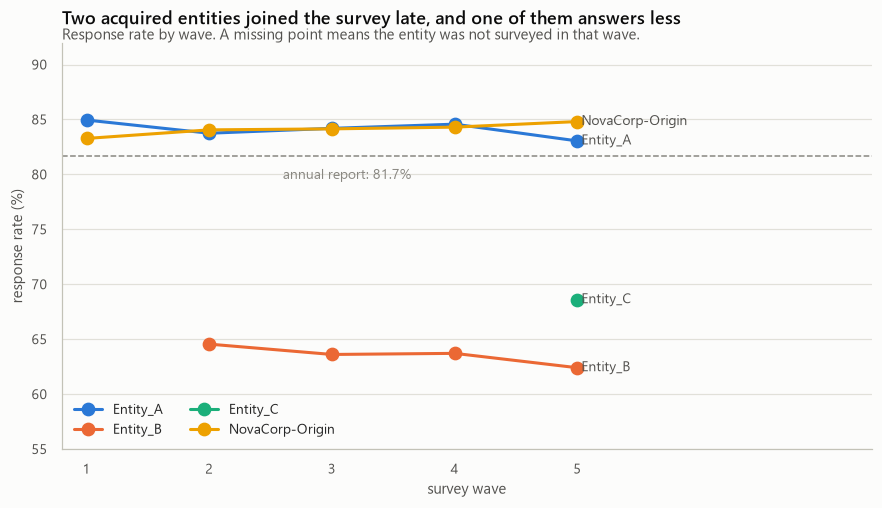

In [9]:
resp_by_entity = (
    eng.merge(emp[["employee_id", "legacy_entity_code"]], on="employee_id", how="left")
    .pivot_table(index="wave_number", columns="legacy_entity_code",
                 values="response_flag", aggfunc="mean")
)

fig, ax = figure(
    "Two acquired entities joined the survey late, and one of them answers less",
    "Response rate by wave. A missing point means the entity was not surveyed in that wave.",
    figsize=(9.5, 4.8),
)

for i, entity in enumerate(resp_by_entity.columns):
    series = resp_by_entity[entity].dropna()
    ax.plot(series.index, 100 * series.values, color=SERIES[i], marker="o", label=entity)
    ax.annotate(f" {entity}", xy=(series.index[-1], 100 * series.values[-1]),
                va="center", fontsize=9, color=INK["secondary"])

ax.axhline(100 * etl.AR_SURVEY_RESPONSE_RATE, color=INK["muted"], lw=1,
           ls="--", zorder=0)
ax.annotate(f"annual report: {pct(etl.AR_SURVEY_RESPONSE_RATE)}",
            xy=(2.6, 100 * etl.AR_SURVEY_RESPONSE_RATE - 1.2), va="top",
            fontsize=9, color=INK["muted"])

ax.set(xlabel="survey wave", ylabel="response rate (%)", xlim=(0.8, 7.4), ylim=(55, 92))
ax.set_xticks(range(1, 6))
ax.legend(loc="lower left", ncols=2)
save_fig(fig, "dq_response_by_entity")
plt.show()

**Read this carefully before doing Angle 3.**

- `Entity_C` appears in wave 5 only. Every one of its 1,014 employees has
  exactly one survey opportunity, so a single non-response makes them "never
  responded". Their 31% never-responded rate is an artefact of exposure.
- `Entity_B` joined at wave 2 and answers at ~63% against ~84% elsewhere.
  That gap is real and persists across four waves: it is a finding.

The fix in `05` is to compare like with like: condition on `waves_issued`, or
use response *rate* rather than the binary "never responded".

## 4. `tenure_months` is stale: recompute it

If `tenure_months` were a live field, then `hire_date + tenure_months` would
land on one snapshot date for every active employee. It does not.

In [10]:
active = emp[emp["status"].str.lower() == "active"]
implied_asof = active["hire_date"] + pd.to_timedelta(active["tenure_months"] * 30.44, unit="D")

print(f"  implied snapshot date, earliest : {implied_asof.min():%d %b %Y}")
print(f"  implied snapshot date, median   : {implied_asof.median():%d %b %Y}")
print(f"  implied snapshot date, latest   : {implied_asof.max():%d %b %Y}")
print(f"  spread                          : {(implied_asof.max() - implied_asof.min()).days} days")

  implied snapshot date, earliest : 02 Dec 2025
  implied snapshot date, median   : 28 Jan 2026
  implied snapshot date, latest   : 22 Jul 2026
  spread                          : 232 days


  saved figures\dq_tenure_staleness.png


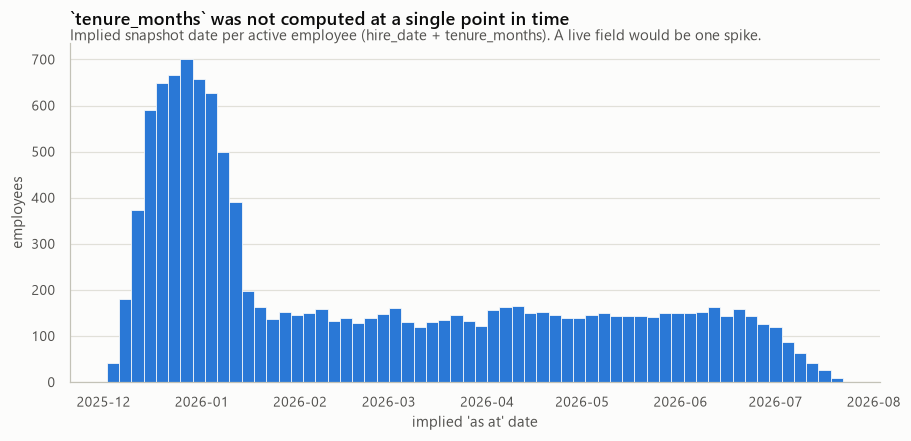

In [11]:
fig, ax = figure(
    "`tenure_months` was not computed at a single point in time",
    "Implied snapshot date per active employee (hire_date + tenure_months). "
    "A live field would be one spike.",
    figsize=(9.5, 4),
)
ax.hist(implied_asof, bins=60, color=SERIES[0], edgecolor=INK["surface"], linewidth=0.5)
ax.set(xlabel="implied 'as at' date", ylabel="employees")
save_fig(fig, "dq_tenure_staleness")
plt.show()

The implied snapshot dates are spread over roughly eight months, so the field
was not computed at one point in time. Anything that bands or cuts by tenure ,
which includes the Culture Amp benchmark comparison: should recompute from
`hire_date` against a stated as-at date instead:

```python
AS_AT = pd.Timestamp("2025-12-31")
tenure = ((df["exit_date"].fillna(AS_AT) - df["hire_date"]).dt.days / 30.44)
```

Before rewriting anything, measure how much the correction actually moves.

In [12]:
AS_AT = pd.Timestamp("2025-12-31")
recomputed = ((df["exit_date"].fillna(AS_AT) - df["hire_date"]).dt.days / 30.44).round(1)
drift = (recomputed - df["tenure_months"]).abs()
rebanded = pd.cut(recomputed, etl.TENURE_BINS, labels=etl.TENURE_LABELS)

print(f"  absolute drift, median : {drift.median():.1f} months")
print(f"  75th percentile        : {drift.quantile(0.75):.1f} months")
print(f"  maximum                : {drift.max():.1f} months")
print(f"  employees drifting >2 months           : {int((drift > 2).sum()):,}")
print(f"  employees whose tenure band would move : {int((rebanded != df['tenure_band']).sum()):,}")

  absolute drift, median : 0.9 months
  75th percentile        : 3.6 months
  maximum                : 6.7 months
  employees drifting >2 months           : 5,260
  employees whose tenure band would move : 122


**Calibrate the response before acting on it.** The field is internally
inconsistent (that part is not arguable) but the practical damage is
limited: around 5,000 employees drift by more than two months, yet only ~120
cross a tenure-band boundary. So:

- For **banding and cohort charts**, `tenure_months` is good enough. Note the
  caveat, do not rebuild the analysis around it.
- For anything using tenure as a **continuous** variable: a survival model,
  a months-to-exit regression: recompute. A two-month error on a 20-month
  tenure is a 10% error on the covariate.

This is the kind of finding worth one line on the DQ slide and no more.

## 5. Everything else checks out

Worth running, worth stating in one line each, not worth a slide.

In [13]:
_windows = eng.merge(emp[["employee_id", "hire_date", "exit_date"]], on="employee_id", how="left")
_out_of_window = int((_windows["survey_date"] < _windows["hire_date"]).sum()
                     + (_windows["survey_date"] > _windows["exit_date"]).sum())


def _case_variants(frame: pd.DataFrame, cols) -> int:
    """Categoricals are trimmed but not case-folded, so `Agency` vs `agency`
    would survive to here. Counts columns where two spellings collide."""
    hits = 0
    for col in cols:
        values = frame[col].dropna().astype(str).unique()
        if len({v.lower() for v in values}) != len(values):
            hits += 1
    return hits


_variant_cols = ["department", "role_family", "hire_source", "contract_type",
                 "status", "legacy_entity_code", "gender"]

checks = [
    ("employee_id unique in roster", emp["employee_id"].is_unique),
    ("no exit before hire", int((emp["exit_date"] < emp["hire_date"]).sum()) == 0),
    ("status agrees with exit_date", int(((emp["status"].str.lower() == "departed") != emp["exit_date"].notna()).sum()) == 0),
    ("every manager_id is a real employee", int(((~emp["manager_id"].isin(emp["employee_id"])) & emp["manager_id"].notna()).sum()) == 0),
    ("no attrition row without an employee", int((~att["employee_id"].isin(emp["employee_id"])).sum()) == 0),
    ("no departed employee missing from the log", int((~emp.loc[emp["status"].str.lower() == "departed", "employee_id"].isin(att["employee_id"])).sum()) == 0),
    ("no survey dated before hire or after exit", _out_of_window == 0),
    ("no case variants in categoricals", _case_variants(emp, _variant_cols) == 0),
]

for label, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label}")

  PASS  employee_id unique in roster
  PASS  no exit before hire
  PASS  status agrees with exit_date
  PASS  every manager_id is a real employee
  PASS  no attrition row without an employee
  PASS  no departed employee missing from the log
  PASS  no survey dated before hire or after exit
  PASS  no case variants in categoricals


### Two things that look like problems and are not

In [14]:
print("  Top salaries, sanity-checked against role level:")
print(df.nlargest(5, "salary")[["job_title", "role_level", "salary", "compa_ratio"]].to_string(index=False))
print("\n  Median salary rises monotonically with role level:")
print(df.groupby("role_level")["salary"].median().to_string())

  Top salaries, sanity-checked against role level:
               job_title  role_level       salary  compa_ratio
 Chief Executive Officer           8 1,206,500.00         1.00
 Chief Financial Officer           7   967,800.00         0.92
 Chief Operating Officer           7   899,100.00         0.92
Chief Technology Officer           7   889,700.00         0.99
      Chief Risk Officer           7   868,700.00         0.89

  Median salary rises monotonically with role level:
role_level
1     101,000.00
2     131,200.00
3     193,100.00
4     296,400.00
5     483,450.00
6     706,850.00
7     851,300.00
8   1,206,500.00


The $1.2M maximum is the CEO, with a compa-ratio of 1.00. Salary is
monotonic in role level across all eight levels. **Do not winsorise**: the
tail is real, and in Angle 1 it is where the replacement cost concentrates.

In [15]:
print(f"  days_to_fill: {df['days_to_fill'].nunique()} distinct values "
      f"spanning {df['days_to_fill'].min():.0f}–{df['days_to_fill'].max():.0f} days")
print(f"  distribution is near-uniform (std {df['days_to_fill'].std():.1f} on a "
      f"{df['days_to_fill'].max() - df['days_to_fill'].min():.0f}-day range)")
print("\n  correlation with anything useful:")
print(df[["days_to_fill", "salary", "role_level", "compa_ratio", "tenure_months"]]
      .corr()["days_to_fill"].round(3).to_string())

  days_to_fill: 77 distinct values spanning 14–90 days
  distribution is near-uniform (std 22.3 on a 76-day range)

  correlation with anything useful:
days_to_fill    1.00
salary          0.00
role_level      0.01
compa_ratio     0.00
tenure_months   0.01


`days_to_fill` is uniform noise and correlates with nothing. It is the
obvious candidate for a "time to hire" chart and it will not support one ,
skip it rather than discovering that on stage.

## 6. What the annual report's 10.4% actually counts

Section 2 established that the headline rate does not reconcile. This section
works out what it does reconcile to, which turns out to be exact.

The test: if the report's "voluntary attrition" were computed as every
departure in the file divided by the full historical roster, the departmental
breakdown on page 8 would fall out of this dataset without adjustment. Seven
departments is enough to rule out coincidence.

In [16]:
# The published departmental rates, transcribed from the FY2025 report, page 8.
PUBLISHED = {
    "Retail Banking": 9.3, "Technology": 10.4, "Risk & Compliance": 11.8,
    "Insurance": 10.3, "Wealth Management": 10.5, "Corporate Operations": 11.6,
    "Executive Leadership": 8.3,
}

roster = emp.groupby("department", observed=True).size()
active = (emp[emp["status"].str.lower() == "active"]
          .groupby("department", observed=True).size())

check = pd.DataFrame({"roster": roster, "active": active})
check["departed"] = check["roster"] - check["active"]
check["computed_pct"] = (100 * check["departed"] / check["roster"]).round(1)
check["published_pct"] = pd.Series(PUBLISHED)
check["match"] = (check["computed_pct"] - check["published_pct"]).abs() < 0.1

print(f"  Departments reconciling exactly: {check['match'].sum()} of {len(check)}")
check

  Departments reconciling exactly: 7 of 7


,roster,active,departed,computed_pct,published_pct,match
department,,,,,,
Corporate Operations,1509,1334,175,11.60,11.60,True
Executive Leadership,230,211,19,8.30,8.30,True
Insurance,1781,1597,184,10.30,10.30,True
Retail Banking,3280,2974,306,9.30,9.30,True
Risk & Compliance,2022,1783,239,11.80,11.80,True
Technology,3032,2717,315,10.40,10.40,True
Wealth Management,1549,1387,162,10.50,10.50,True


In [17]:
# The same formula at company level, and the three things wrong with the label.
total_roster, total_active = len(emp), int((emp["status"].str.lower() == "active").sum())
all_exits = len(att)
voluntary = int(att["exit_type"].str.lower().eq("voluntary").sum())
involuntary = all_exits - voluntary

print("  The published formula")
print(f"    full historical roster            {total_roster:>7,}")
print(f"    still active                      {total_active:>7,}")
print(f"    difference, all departures        {all_exits:>7,}   over 24 months")
print(f"    {all_exits:,} / {total_roster:,}                    "
      f"{100 * all_exits / total_roster:>6.1f}%   published: 10.4%")

print("\n  What the label gets wrong")
print(f"    1. not voluntary   {involuntary:,} of {all_exits:,} exits are involuntary "
      f"({100 * involuntary / all_exits:.0f}%)")
print(f"    2. not annual      the window is 24 months, not 12")
print(f"    3. not headcount   denominator is the roster, not the {total_active:,} active")

print("\n  Corrected, on the same data")
per_year = voluntary / etl.OBS_YEARS
print(f"    voluntary exits, 24 months        {voluntary:>7,}")
print(f"    per year                          {per_year:>7,.0f}")
print(f"    against {total_active:,} active            {100 * per_year / total_active:>6.1f}%")

# The rate depends on which twelve months are chosen, so give the range.
att_dates = att.assign(vol=att["exit_type"].str.lower().eq("voluntary"))
windows = {
    "FY2025 (Jul 24 to Jun 25)": ("2024-07-01", "2025-06-30"),
    "calendar 2024": ("2024-01-01", "2024-12-31"),
    "calendar 2025": ("2025-01-01", "2025-12-31"),
}
print("\n  Sensitivity to the twelve months chosen")
for label, (lo, hi) in windows.items():
    n = int((att_dates["vol"] & att_dates["exit_date"].between(lo, hi)).sum())
    print(f"    {label:<28} {n:>4} exits   {100 * n / total_active:>5.1f}%")

  The published formula


    full historical roster             13,403
    still active                       12,003
    difference, all departures          1,400   over 24 months
    1,400 / 13,403                      10.4%   published: 10.4%

  What the label gets wrong
    1. not voluntary   267 of 1,400 exits are involuntary (19%)
    2. not annual      the window is 24 months, not 12
    3. not headcount   denominator is the roster, not the 12,003 active

  Corrected, on the same data
    voluntary exits, 24 months          1,133
    per year                              566
    against 12,003 active               4.7%

  Sensitivity to the twelve months chosen
    FY2025 (Jul 24 to Jun 25)     683 exits     5.7%
    calendar 2024                 552 exits     4.6%
    calendar 2025                 581 exits     4.8%


### What this changes

The formula reconciles on all seven departments and at company level, so there
is no ambiguity about what was computed. Three things are wrong with the label,
and all three push the published figure in the same direction:

- **Not voluntary.** 267 of the 1,400 departures are involuntary exits.
- **Not annual.** The window is 24 months.
- **Not headcount.** The denominator includes everyone who left.

Corrected, annual voluntary attrition is **4.7%**, running between 4.6% and 5.7%
depending on which twelve months are chosen.

Two consequences worth carrying forward:

1. **The FY2026 target is measuring the wrong quantity.** Guidance sets
   voluntary attrition below 9.5% against a stated 10.4%. On a like-for-like
   basis the company has been at roughly half that for both years in the data,
   so a programme could succeed or fail without the metric moving.
2. **NovaCorp does not have a volume problem.** Against AHRI's 15.2% Australian
   organisational average for December 2025 and ABS Financial and Insurance
   Services job mobility of 7.9%, it is losing people slowly. Which component of
   the $42M is worth attention becomes a question about *who* leaves, not how
   many, and that is what Angle 1 goes on to test.

The departmental *ranking* is unaffected: every department is computed the same
way, so Risk and Compliance sitting above the firm average remains true.

## Carry these forward

1. **The $42M is a floor.** The attrition log covers 24 months but only
   reconciles to 60% of the annual report's FY2025 departures. → Angle 1.
2. **Never-responded is confounded by exposure.** Condition on
   `waves_issued` or the Entity_C artefact will masquerade as a finding.
   → Angle 3.
3. **December 2025 is censored.** Any post-period window that runs to the end
   of the data is short by most of a month. → Angle 2's event study.
4. **`tenure_months` is stale but survivable.** Fine for bands, wrong for any
   model that uses tenure continuously.
5. No imputation is required anywhere, and no outlier should be trimmed.